# BESS Dispatch Analysis

This notebook runs the BESS (Battery Energy Storage System) strategy over the same period as the virtual trading backtest and analyses dispatch behaviour across four sections:

1. **Performance Summary** — Net PnL, Sharpe ratio, max drawdown, and degradation cost
2. **Revenue Decomposition** — Component-level PnL breakdown, waterfall chart, and degradation vs. revenue
3. **Dispatch Behaviour** — Price-dispatch-SOC showcase, SOC heatmap, rebalancing impact, and dispatch efficiency
4. **Risk Profile** — Executive summary with PnL waterfall, dispatch duration curve, and daily PnL distribution

The strategy uses LP optimisation (PuLP/HiGHS) for Day-Ahead scheduling and a three-rule intraday engine for real-time adjustments. The DA schedule is optimised against an **ML DA price forecast** loaded from the artifact directory, matching production pipeline behaviour. If no trained BESS model is found, the notebook falls back to realised DA prices (oracle upper bound).

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import json as _json
import sys
from pathlib import Path

import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.bess.bess_asset import BESSAsset
from src.bess.da_optimizer import optimize_da_schedule
from src.bess.intraday_manager import run_intraday_session
from src.utils.config import load_config

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

COLORS = {
    "da":          "#2196F3",
    "intraday":    "#4CAF50",
    "imbalance":   "#F44336",
    "degradation": "#FF9800",
    "net":         "#9E9E9E",
}

_best_run_path = REPO_ROOT / "artifacts" / "da_positioning" / "best_run.json"
_best_run = (
    _json.loads(_best_run_path.read_text())["best_run"]
    if _best_run_path.exists() else "s4_n10_t50_tc10"
)
ARTIFACT_DIR     = REPO_ROOT / "artifacts" / "da_positioning" / _best_run
STARTING_CAPITAL = 50_000.0

# Load config — fall back to example template if local config.yaml is absent
_cfg_path     = REPO_ROOT / "configs" / "config.yaml"
_cfg_fallback = REPO_ROOT / "configs" / "config.example.yaml"
config   = load_config(_cfg_path if _cfg_path.exists() else _cfg_fallback)
BESS_CFG = config["bess"]

# Load the trained BESS DA price model if present
_model_path = ARTIFACT_DIR / "bess" / "model" / "model.joblib"
_meta_path  = ARTIFACT_DIR / "bess" / "model" / "metadata.json"
if _model_path.exists() and _meta_path.exists():
    DA_FORECAST_MODEL    = joblib.load(_model_path)
    DA_FORECAST_FEATURES = _json.loads(_meta_path.read_text())["features"]
    USE_ML_FORECAST      = True
    print(f"Using artifact      : {_best_run}")
    print(f"DA forecast model loaded ({len(DA_FORECAST_FEATURES)} features)")
else:
    DA_FORECAST_MODEL    = None
    DA_FORECAST_FEATURES = []
    USE_ML_FORECAST      = False
    print(f"Using artifact      : {_best_run}")
    print("WARNING: No BESS model found — falling back to oracle (realised) DA prices")


Using artifact      : s4_n10_t50_tc10


---
## Helpers

Reusable data-loading functions. All paths resolve against `ARTIFACT_DIR` set above.

In [2]:
def load_features() -> pd.DataFrame:
    """Load the feature/price parquet from the shared artifact."""
    df = pd.read_parquet(ARTIFACT_DIR / "features" / "features.parquet")
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df.set_index("time").sort_index()


def load_virtual_signals() -> pd.DataFrame:
    """Load virtual strategy signals CSV from the shared artifact."""
    df = pd.read_csv(
        ARTIFACT_DIR / "virtual" / "trading" / "signals.csv",
        parse_dates=["delivery_time"],
    )
    df["delivery_time"] = pd.to_datetime(df["delivery_time"], utc=True)
    return df


def load_virtual_pnl() -> pd.DataFrame:
    """Load virtual strategy PnL CSV from the shared artifact."""
    df = pd.read_csv(
        ARTIFACT_DIR / "virtual" / "trading" / "pnl.csv",
        parse_dates=["time"],
    )
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df

---
## Data Loading

Load the feature/price dataset and the virtual signals from the shared artifact. The analysis period is pinned to the virtual strategy's walk-forward test window so both strategies are evaluated on identical dates.

In [3]:
features_df = load_features()

# Derive the analysis period from the virtual signals (walk-forward test window)
_signals = load_virtual_signals()
ANALYSIS_START = _signals["delivery_time"].min()
ANALYSIS_END   = _signals["delivery_time"].max()

# Filter features to the analysis period
features_period = features_df.loc[ANALYSIS_START:ANALYSIS_END]

# Resample to hourly — BESS LP and intraday manager operate at 1-hour resolution
prices = (
    features_period[["day_ahead_price", "mid_price", "system_buy_price", "system_sell_price"]]
    .resample("1h").mean()
    .dropna()
)

# BESSAsset asset kwargs
_ASSET_FIELDS = {"capacity_mwh", "power_mw", "charge_efficiency",
                 "discharge_efficiency", "degradation_cost_per_mwh", "initial_soc_pct"}
asset_kwargs = {k: v for k, v in BESS_CFG.items() if k in _ASSET_FIELDS}

features_period_london = features_period.copy()
features_period_london.index = features_period_london.index.tz_convert("Europe/London")

print(f"Analysis period : {ANALYSIS_START.date()} → {ANALYSIS_END.date()}")
print(f"Price rows (1h) : {len(prices)}")
print(f"Feature rows    : {len(features_period)}")

Analysis period : 2018-07-21 → 2018-12-18
Price rows (1h) : 3513
Feature rows    : 7202


---
## BESS Backtest

Run the BESS pipeline day-by-day over the analysis period. The DA schedule is solved by LP against the **ML DA price forecast** (loaded from the artifact), matching production pipeline behaviour. Intraday rules execute against MID and imbalance prices in the delivery window. Falls back to realised DA prices if no trained model is present.

In [ ]:
daily_results    = []
all_dispatch_logs = []
all_da_schedules  = []

# Persistent asset — SOC carries over day-to-day instead of resetting to 50%
asset        = BESSAsset(**asset_kwargs)
prev_soc_pct = None

for date, day_df in prices.groupby(prices.index.date):
    n_hours = len(day_df)
    if n_hours not in {23, 24, 25}:
        continue

    da_prices  = day_df["day_ahead_price"].tolist()
    mid_prices = day_df["mid_price"].tolist()
    sbp_prices = day_df["system_buy_price"].tolist()
    ssp_prices = day_df["system_sell_price"].tolist()

    # DA schedule: use ML forecast when model is available, else oracle (realised) prices
    if USE_ML_FORECAST:
        day_feat = features_period.loc[
            features_period.index.date == date, DA_FORECAST_FEATURES
        ].dropna()
        if len(day_feat) >= n_hours * 2:
            raw_fc = DA_FORECAST_MODEL.predict(day_feat).tolist()
            da_forecast = [
                (raw_fc[i] + raw_fc[i + 1]) / 2
                for i in range(0, n_hours * 2, 2)
            ]
        else:
            da_forecast = da_prices
    else:
        da_forecast = da_prices

    carry_soc = prev_soc_pct if prev_soc_pct is not None else BESS_CFG["initial_soc_pct"]
    asset.reset(soc_pct=carry_soc)
    schedule = optimize_da_schedule(da_forecast, asset)

    asset.reset(soc_pct=carry_soc)
    result = run_intraday_session(
        da_schedule=schedule,
        da_price_actual=da_prices,
        mid_prices=mid_prices,
        imbalance_prices=sbp_prices,
        asset=asset,
        config=BESS_CFG,
        imbalance_sell_prices=ssp_prices,
    )
    prev_soc_pct = asset.soc_pct

    daily_results.append({
        "date":             pd.Timestamp(date),
        "da_revenue":       result["da_revenue"],
        "intraday_pnl":     result["intraday_pnl"],
        "imbalance_pnl":    result["imbalance_pnl"],
        "degradation_cost": result["total_degradation_cost"],
        "net_pnl":          result["net_pnl"],
    })

    for entry in result["dispatch_log"]:
        entry["date"] = date
        entry["hour"] = entry["period"]
        entry["timestamp"] = day_df.index[entry["period"]]
    all_dispatch_logs.extend(result["dispatch_log"])

    for h, mw in enumerate(schedule):
        all_da_schedules.append({
            "date":      date,
            "hour":      h,
            "timestamp": day_df.index[h],
            "da_mw":     mw,
        })

results_df  = pd.DataFrame(daily_results)
dispatch_df = pd.DataFrame(all_dispatch_logs)
da_sched_df = pd.DataFrame(all_da_schedules)

print(f"Backtest complete : {len(results_df)} days")
print(f"Total net PnL     : £{results_df['net_pnl'].sum():,.0f}")
print(f"Mean daily PnL    : £{results_df['net_pnl'].mean():,.0f}")

---
## Section 1: Performance Summary

Key risk-return metrics for the BESS strategy over the full backtest period.

In [5]:
avg_daily   = results_df["net_pnl"].mean()
std_daily   = results_df["net_pnl"].std(ddof=1)
total_net   = results_df["net_pnl"].sum()
total_ret   = total_net / STARTING_CAPITAL
sharpe      = (avg_daily / std_daily) * np.sqrt(365) if std_daily > 0 else 0.0

cumulative  = results_df["net_pnl"].cumsum()
peak        = cumulative.cummax()
max_dd      = (cumulative - peak).min()
calmar      = total_ret / (abs(max_dd) / STARTING_CAPITAL) if max_dd < 0 else float("nan")

neg_ret     = results_df.loc[results_df["net_pnl"] < 0, "net_pnl"]
downside    = np.sqrt((neg_ret ** 2).mean()) if len(neg_ret) > 0 else float("nan")
sortino     = (avg_daily / downside) * np.sqrt(365) if (downside and downside > 0) else float("nan")

win_rate    = (results_df["net_pnl"] > 0).mean()
avg_win     = results_df.loc[results_df["net_pnl"] > 0, "net_pnl"].mean()
avg_loss    = results_df.loc[results_df["net_pnl"] < 0, "net_pnl"].mean()

total_deg   = results_df["degradation_cost"].sum()
deg_per_mwh = BESS_CFG["degradation_cost_per_mwh"]
throughput  = total_deg / deg_per_mwh if deg_per_mwh > 0 else 0.0
cycles      = throughput / (2 * BESS_CFG["capacity_mwh"]) if BESS_CFG["capacity_mwh"] > 0 else 0.0
net_per_mwh = total_net / throughput if throughput > 0 else float("nan")
cap_factor  = throughput / (BESS_CFG["power_mw"] * 24 * len(results_df)) if results_df.shape[0] > 0 else float("nan")

_fmt = lambda v, f: f if not (isinstance(v, float) and np.isnan(v)) else "—"
summary = pd.DataFrame({
    "Metric": [
        "Net PnL",            "Total Return",        "Sharpe (ann.)",
        "Calmar Ratio",       "Sortino Ratio",        "Max Drawdown",
        "Win Rate",           "Avg Win Day",          "Avg Loss Day",
        "Days Traded",        "MWh Throughput",       "Total Cycles",
        "Net £/MWh",          "Degradation Cost",     "Capacity Factor",
    ],
    "Value": [
        f"£{total_net:,.0f}",
        f"{total_ret:+.1%}",
        _fmt(sharpe,      f"{sharpe:.2f}"),
        _fmt(calmar,      f"{calmar:.2f}"),
        _fmt(sortino,     f"{sortino:.2f}"),
        f"£{max_dd:,.0f}",
        f"{win_rate:.1%}",
        _fmt(avg_win,     f"£{avg_win:,.0f}"),
        _fmt(avg_loss,    f"£{avg_loss:,.0f}"),
        f"{len(results_df)}",
        f"{throughput:,.0f} MWh",
        f"{cycles:.1f}",
        _fmt(net_per_mwh, f"£{net_per_mwh:.2f}/MWh"),
        f"£{total_deg:,.0f}",
        _fmt(cap_factor,  f"{cap_factor:.1%}"),
    ],
}).set_index("Metric")

summary.style.set_properties(**{"text-align": "right"})


,Value
Metric,
Net PnL,"£173,837"
Total Return,+347.7%
Sharpe (ann.),20.01
Calmar Ratio,—
Sortino Ratio,—
Max Drawdown,£0
Win Rate,98.6%
Avg Win Day,"£1,224"
Avg Loss Day,—


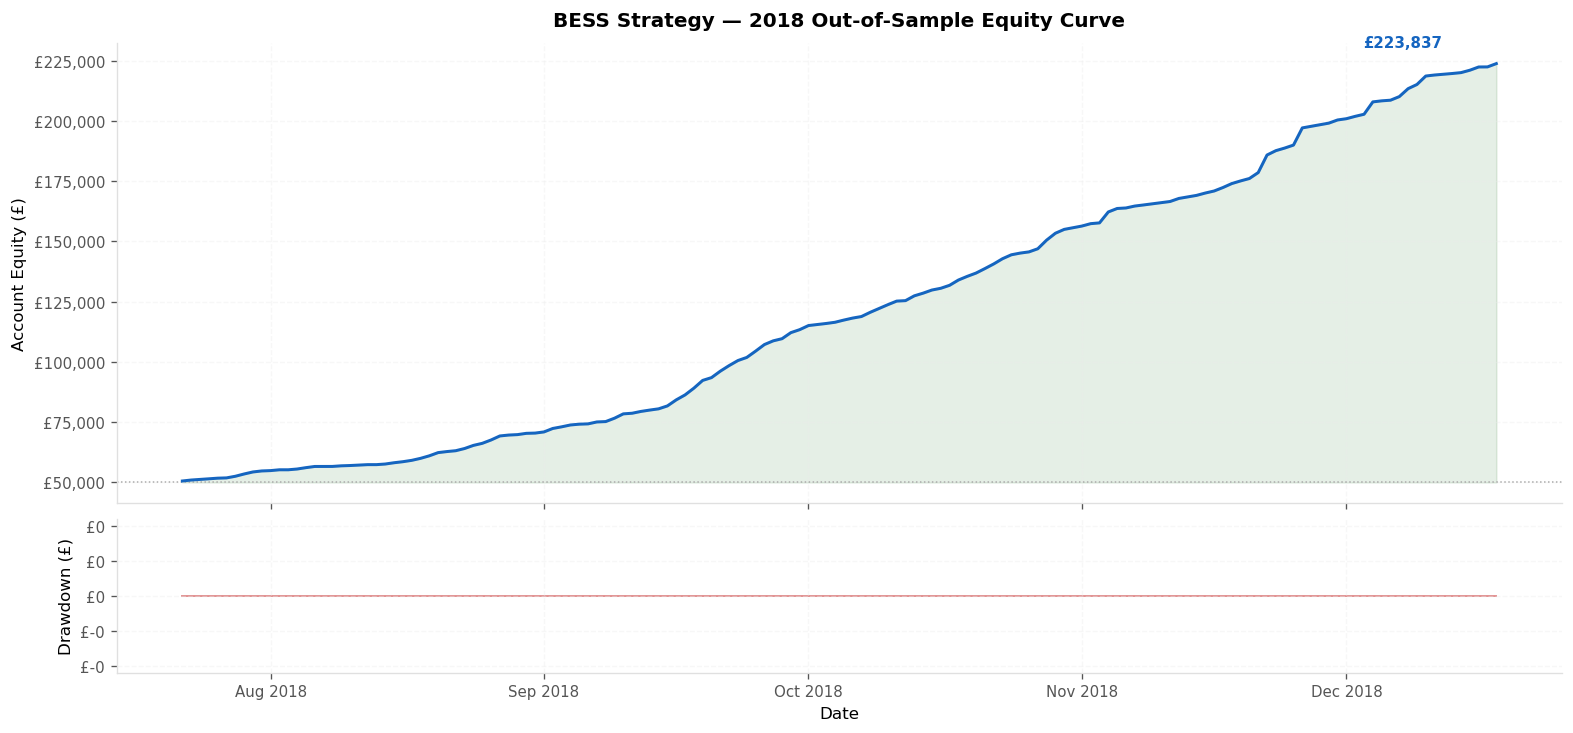

In [6]:
# ── Equity curve + drawdown ───────────────────────────────────────────────────
_eq = STARTING_CAPITAL + results_df.set_index("date")["net_pnl"].cumsum()
_dd = _eq - _eq.cummax()

fig, (ax_eq, ax_dd) = plt.subplots(
    2, 1, figsize=(13, 6), sharex=True, layout="constrained",
    gridspec_kw={"height_ratios": [3, 1]},
)
ax_eq.plot(_eq.index, _eq.values, color="#1565C0", linewidth=1.8, zorder=3)
ax_eq.fill_between(_eq.index, STARTING_CAPITAL, _eq.values,
                   where=(_eq.values >= STARTING_CAPITAL), alpha=0.12, color="#2E7D32")
ax_eq.fill_between(_eq.index, STARTING_CAPITAL, _eq.values,
                   where=(_eq.values < STARTING_CAPITAL), alpha=0.15, color="#C62828")
ax_eq.axhline(STARTING_CAPITAL, color="#aaaaaa", linestyle=":", linewidth=0.9)
ax_eq.annotate(f"£{_eq.iloc[-1]:,.0f}",
               xy=(_eq.index[-1], _eq.iloc[-1]),
               xytext=(-80, 10), textcoords="offset points",
               fontsize=9, color="#1565C0", fontweight="bold")
ax_eq.set_ylabel("Account Equity (£)", fontsize=10)
ax_eq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax_eq.set_title("BESS Strategy — 2018 Out-of-Sample Equity Curve", fontsize=12, fontweight="bold", pad=10)

ax_dd.fill_between(_dd.index, _dd.values, 0, alpha=0.5, color="#C62828")
ax_dd.set_ylabel("Drawdown (£)", fontsize=10)
ax_dd.set_xlabel("Date", fontsize=10)
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_dd.xaxis.set_major_locator(mdates.MonthLocator())

for ax in (ax_eq, ax_dd):
    ax.spines["left"].set_color("#e0e0e0")
    ax.spines["bottom"].set_color("#e0e0e0")
    ax.grid(True, alpha=0.4, color="#ebebeb", linestyle="--")
    ax.tick_params(colors="#555555", labelsize=9)

plt.show()


---
## Section 2: Revenue Decomposition

Component-level breakdown of total net PnL. Each row maps directly to a column in `results_df`:

| Component | Source Column |
|---|---|
| Day-Ahead Revenue | `da_revenue` |
| Intraday / Rebalancing PnL | `intraday_pnl` |
| Imbalance Costs | `imbalance_pnl` |
| Degradation Costs | `degradation_cost` (sign-flipped) |

,Amount,Share
Component,,
Day-Ahead Revenue,"£401,052",230.7%
Intraday / Rebalancing PnL,"£-8,081",-4.6%
Imbalance PnL,"£10,006",5.8%
Degradation Costs,"£-229,140",-131.8%


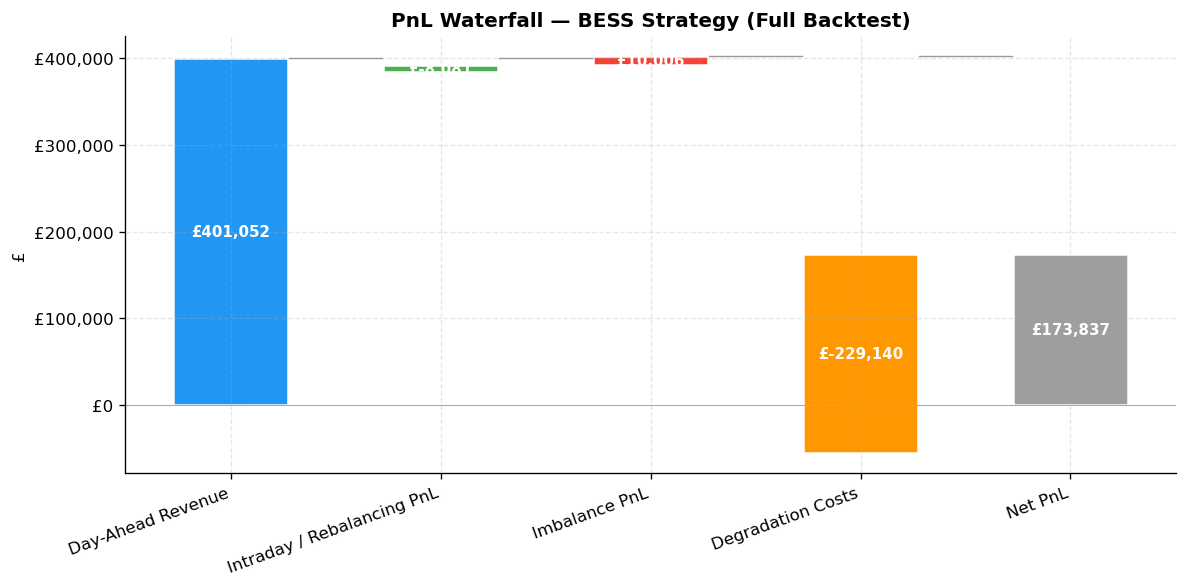

In [7]:
decomp = pd.DataFrame([
    {"Component": "Day-Ahead Revenue",          "Amount": results_df["da_revenue"].sum()},
    {"Component": "Intraday / Rebalancing PnL", "Amount": results_df["intraday_pnl"].sum()},
    {"Component": "Imbalance PnL",              "Amount": results_df["imbalance_pnl"].sum()},
    {"Component": "Degradation Costs",          "Amount": -results_df["degradation_cost"].sum()},
]).set_index("Component")

net_pnl = decomp["Amount"].sum()
decomp["Share"] = decomp["Amount"] / abs(net_pnl) * 100

display(
    decomp.style
    .format({"Amount": "£{:,.0f}", "Share": "{:.1f}%"})
    .set_properties(**{"text-align": "right"})
)

# ── Waterfall bridge chart ────────────────────────────────────────────────────
wf_labels = list(decomp.index) + ["Net PnL"]
wf_values = list(decomp["Amount"]) + [net_pnl]

running = 0.0
bottoms = []
for v in list(decomp["Amount"]):
    bottoms.append(running if v >= 0 else running + v)
    running += v
bottoms.append(0.0)

bar_colors = [
    COLORS["da"], COLORS["intraday"], COLORS["imbalance"],
    COLORS["degradation"], COLORS["net"],
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(wf_labels)), wf_values, bottom=bottoms,
              color=bar_colors, width=0.55, edgecolor="white", linewidth=1.5)

# Connector lines between bars
running2 = 0.0
for i, v in enumerate(list(decomp["Amount"])):
    top = running2 + v if v >= 0 else running2
    ax.plot([i + 0.28, i + 0.72], [top, top], color="#999999", linewidth=0.8, zorder=4)
    running2 += v

for bar, val in zip(bars, wf_values):
    y = bar.get_y() + bar.get_height() / 2
    ax.text(bar.get_x() + bar.get_width() / 2, y, f"£{val:,.0f}",
            ha="center", va="center", fontsize=9, fontweight="bold", color="white")

ax.set_xticks(range(len(wf_labels)))
ax.set_xticklabels(wf_labels, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("£", fontsize=10)
ax.set_title("PnL Waterfall — BESS Strategy (Full Backtest)", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.axhline(0, color="#aaaaaa", linewidth=0.6)
plt.tight_layout()
plt.show()


### Monthly Revenue Breakdown

Monthly stacked revenue by settlement layer with cumulative net PnL overlay. Reveals seasonality and month-to-month consistency in the charge/discharge cycle.

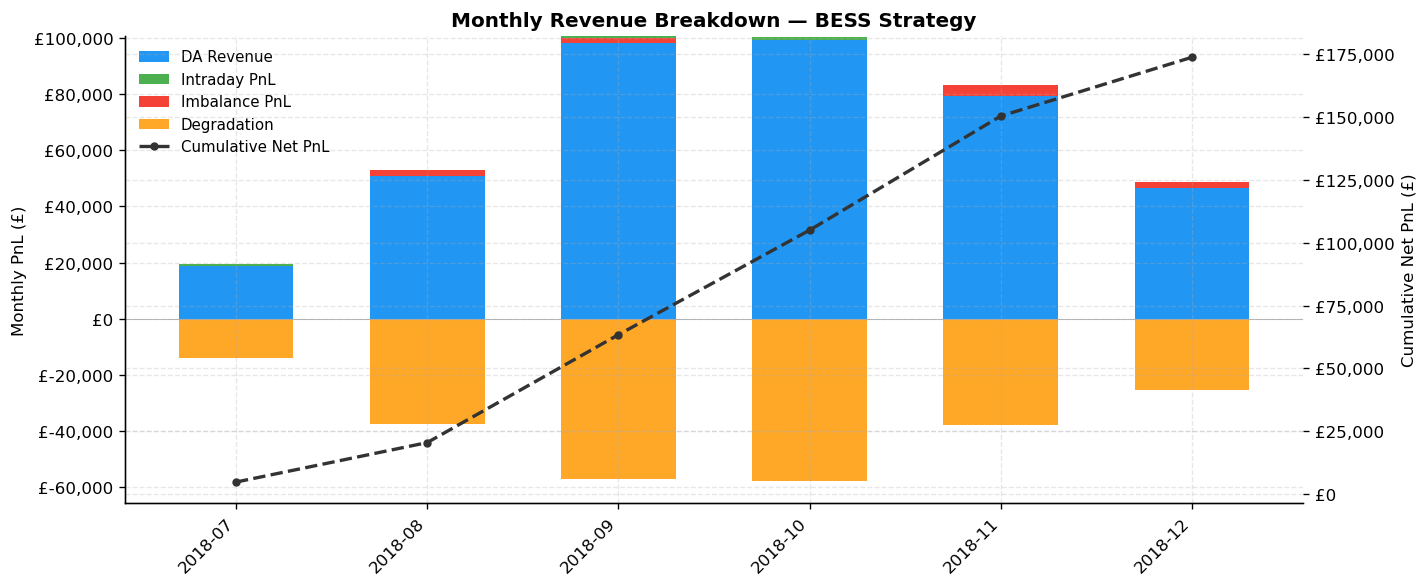

In [8]:
monthly = (
    results_df.assign(month=results_df["date"].dt.to_period("M"))
    .groupby("month")
    .agg(da_revenue=("da_revenue", "sum"),
         intraday_pnl=("intraday_pnl", "sum"),
         imbalance_pnl=("imbalance_pnl", "sum"),
         degradation_cost=("degradation_cost", "sum"),
         net_pnl=("net_pnl", "sum"))
    .reset_index()
)
monthly["month_str"] = monthly["month"].astype(str)

x = np.arange(len(monthly))
w = 0.6

fig, ax = plt.subplots(figsize=(12, 5))

# Positive revenue stacked; degradation as negative bar
ax.bar(x, monthly["da_revenue"], w, label="DA Revenue",    color=COLORS["da"])
ax.bar(x, monthly["intraday_pnl"], w, bottom=monthly["da_revenue"],
       label="Intraday PnL", color=COLORS["intraday"])
ax.bar(x, monthly["imbalance_pnl"], w,
       bottom=monthly["da_revenue"] + monthly["intraday_pnl"],
       label="Imbalance PnL", color=COLORS["imbalance"])
ax.bar(x, -monthly["degradation_cost"], w, label="Degradation",
       color=COLORS["degradation"], alpha=0.85)

# Cumulative net PnL on right axis
ax2 = ax.twinx()
ax2.plot(x, monthly["net_pnl"].cumsum(), color="#333333", linewidth=2,
         linestyle="--", marker="o", markersize=4, label="Cumulative Net PnL")
ax2.set_ylabel("Cumulative Net PnL (£)", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:,.0f}"))
ax2.spines["top"].set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(monthly["month_str"], rotation=45, ha="right")
ax.set_ylabel("Monthly PnL (£)", fontsize=10)
ax.set_title("Monthly Revenue Breakdown — BESS Strategy", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:,.0f}"))
ax.axhline(0, color="#aaaaaa", linewidth=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


### Degradation vs. Gross Revenue

Cumulative degradation cost plotted against cumulative gross revenue (DA + intraday + imbalance). The gap is the net benefit of battery cycling.

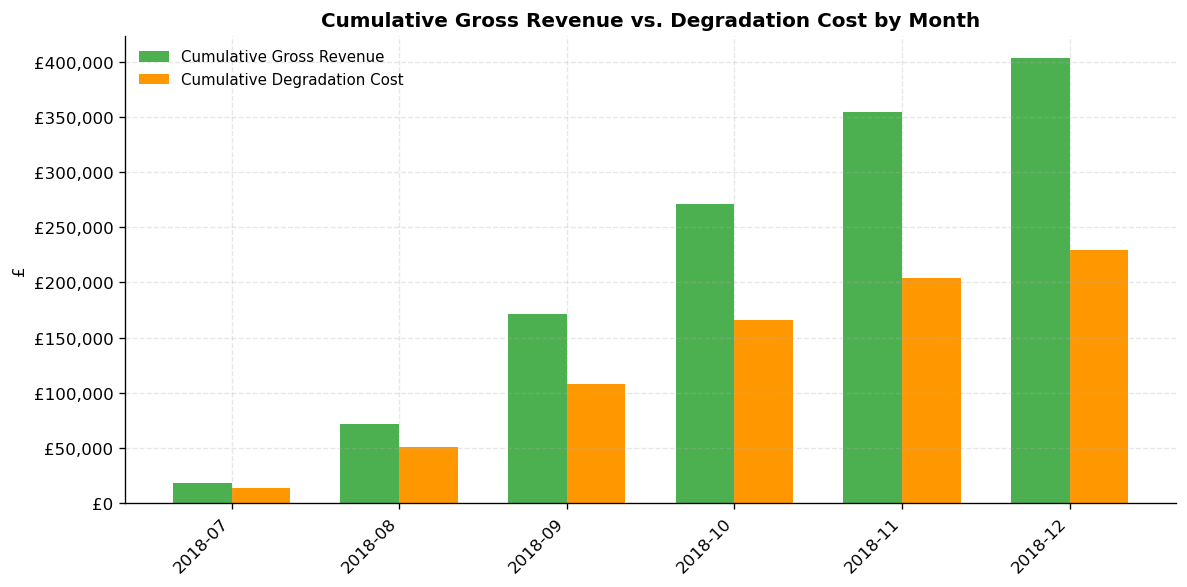

Net benefit of cycles : £173,837
Gross revenue         : £402,978
Degradation cost      : £229,140
Gross/Degradation     : 1.8×


In [9]:
_monthly = (
    results_df.assign(month=results_df["date"].dt.to_period("M"))
    .groupby("month")
    .agg(gross_rev=("da_revenue", "sum"),
         intraday=("intraday_pnl", "sum"),
         imbalance=("imbalance_pnl", "sum"),
         deg=("degradation_cost", "sum"))
    .reset_index()
)
_monthly["gross"] = _monthly["gross_rev"] + _monthly["intraday"] + _monthly["imbalance"]
_monthly["cum_gross"] = _monthly["gross"].cumsum()
_monthly["cum_deg"]   = _monthly["deg"].cumsum()
_monthly["month_str"] = _monthly["month"].astype(str)

x = np.arange(len(_monthly))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, _monthly["cum_gross"], w, label="Cumulative Gross Revenue", color=COLORS["intraday"])
ax.bar(x + w/2, _monthly["cum_deg"],   w, label="Cumulative Degradation Cost", color=COLORS["degradation"])
ax.set_xticks(x)
ax.set_xticklabels(_monthly["month_str"], rotation=45, ha="right")
ax.set_ylabel("£", fontsize=10)
ax.set_title("Cumulative Gross Revenue vs. Degradation Cost by Month", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:,.0f}"))
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

net_benefit = _monthly["cum_gross"].iloc[-1] - _monthly["cum_deg"].iloc[-1]
print(f"Net benefit of cycles : £{net_benefit:,.0f}")
print(f"Gross revenue         : £{_monthly['cum_gross'].iloc[-1]:,.0f}")
print(f"Degradation cost      : £{_monthly['cum_deg'].iloc[-1]:,.0f}")
print(f"Gross/Degradation     : {_monthly['cum_gross'].iloc[-1] / _monthly['cum_deg'].iloc[-1]:.1f}×")


---
## Section 3: Dispatch Behaviour

Analysis of the BESS dispatch strategy across multiple dimensions: the core charge/discharge logic on a representative day, SOC health across all backtest days, rebalancing impact, and DA-to-actual dispatch fidelity.

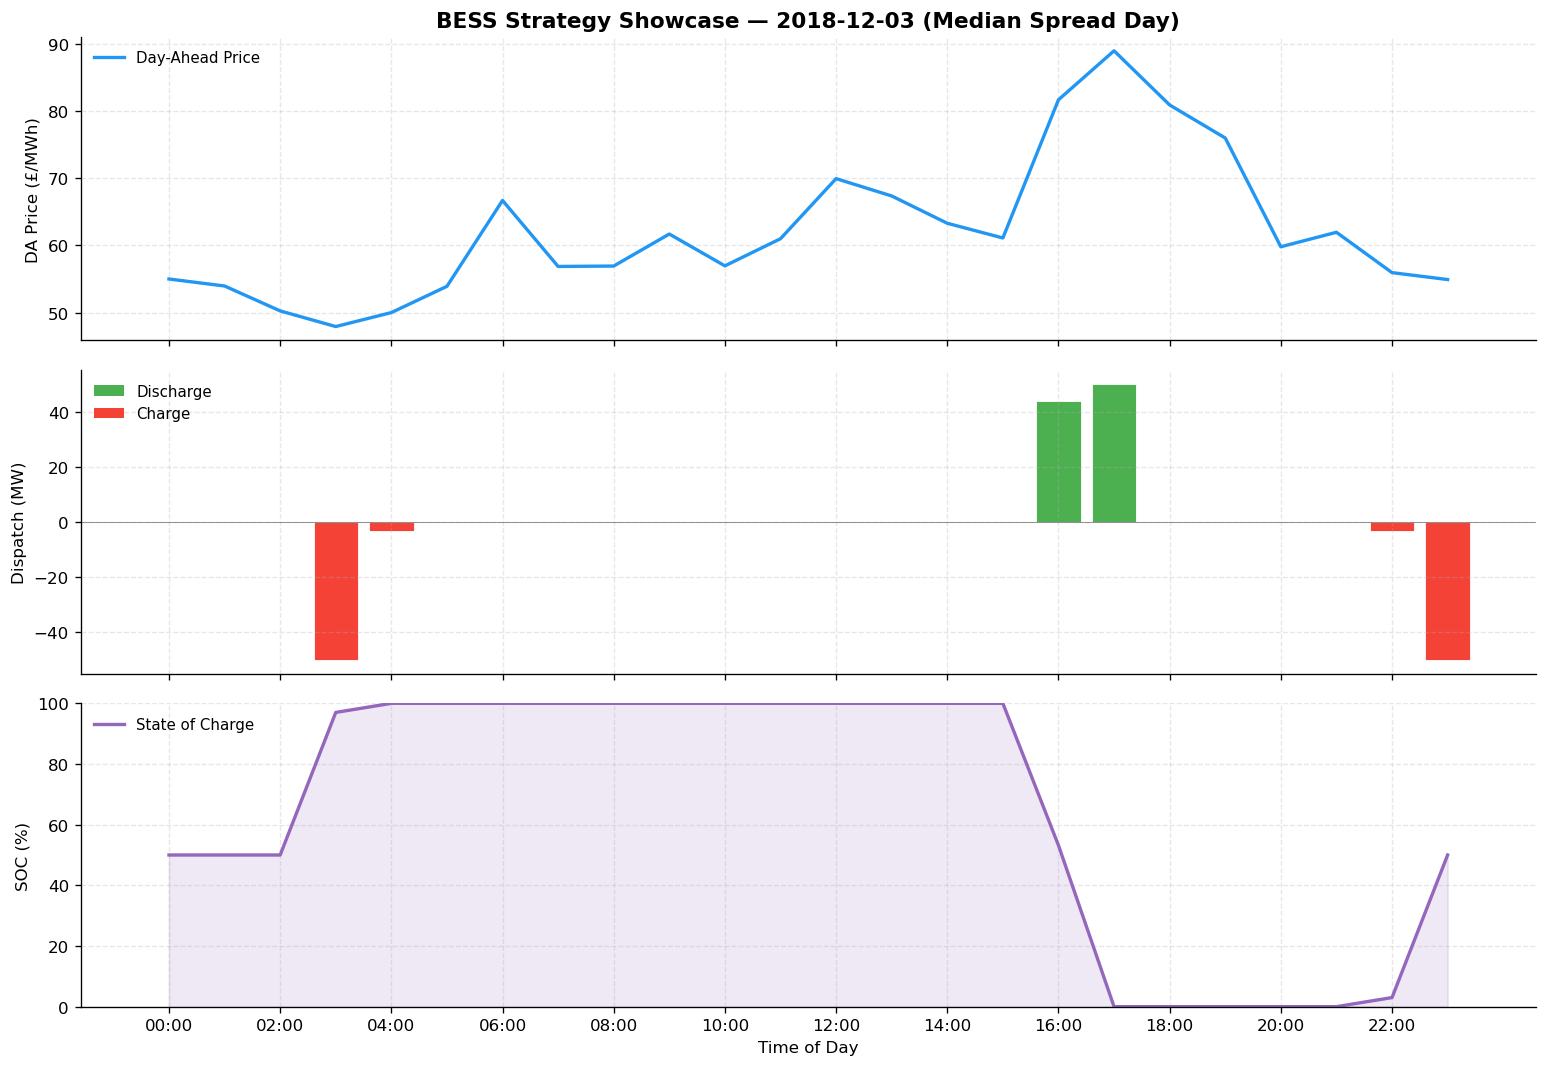

Selected day: 2018-12-03 | DA spread: £41.1/MWh (median: £40.8/MWh)


In [10]:
# Select the day with the median absolute DA spread (representative, not best)
valid_dates = set(da_sched_df["date"].unique())
mask = np.array([d in valid_dates for d in prices.index.date])
valid_prices = prices[mask]
daily_spread = valid_prices.groupby(valid_prices.index.date)["day_ahead_price"].apply(
    lambda x: x.max() - x.min()
)
median_spread = daily_spread.median()
sample_date = daily_spread.iloc[(daily_spread - median_spread).abs().argsort()[:1]].index[0]

# Extract data for the selected day
day_prices = prices.loc[prices.index.date == sample_date]
day_sched = da_sched_df[da_sched_df["date"] == sample_date].sort_values("hour")
day_dispatch = dispatch_df[dispatch_df["date"] == sample_date].sort_values("hour")

da_mw = day_sched["da_mw"].values
n_hours = len(da_mw)
hours = np.arange(n_hours)

soc_series = day_dispatch["soc_after"].values * 100
time_labels = [f"{h:02d}:00" for h in hours]

# ── 3-Panel Figure ────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

ax1.plot(hours, day_prices["day_ahead_price"].values[:n_hours], color=COLORS["da"], linewidth=2)
ax1.set_ylabel("DA Price (£/MWh)")
ax1.set_title(f"BESS Strategy Showcase — {sample_date} (Median Spread Day)", fontsize=13, fontweight="bold")
ax1.legend(["Day-Ahead Price"], frameon=False, fontsize=9, loc="upper left")

bar_colors = [COLORS["intraday"] if mw > 0 else COLORS["imbalance"] if mw < 0 else "#cccccc" for mw in da_mw]
ax2.bar(hours, da_mw, color=bar_colors, width=0.8, edgecolor="white", linewidth=0.5)
ax2.axhline(0, color="grey", linewidth=0.5)
ax2.set_ylabel("Dispatch (MW)")
from matplotlib.patches import Patch
ax2.legend(
    handles=[Patch(facecolor=COLORS["intraday"], label="Discharge"),
             Patch(facecolor=COLORS["imbalance"], label="Charge")],
    frameon=False, fontsize=9, loc="upper left",
)

ax3.plot(hours[:len(soc_series)], soc_series, color="#9467bd", linewidth=2)
ax3.fill_between(hours[:len(soc_series)], 0, soc_series, alpha=0.15, color="#9467bd")
ax3.set_ylim(0, 100)
ax3.set_ylabel("SOC (%)")
ax3.set_xlabel("Time of Day")
ax3.legend(["State of Charge"], frameon=False, fontsize=9, loc="upper left")

ax3.set_xticks(hours[::2])
ax3.set_xticklabels([time_labels[i] for i in range(0, n_hours, 2)])

plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
plt.savefig("assets/bess_strategy_showcase.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Selected day: {sample_date} | DA spread: £{daily_spread[sample_date]:.1f}/MWh (median: £{median_spread:.1f}/MWh)")

### SOC Health Distribution

A 2D heatmap showing how SOC is distributed across time-of-day over all backtest days. This reveals the **typical SOC envelope** — where the battery spends most of its time at each hour — and highlights structural patterns in the optimiser's charge/discharge schedule.

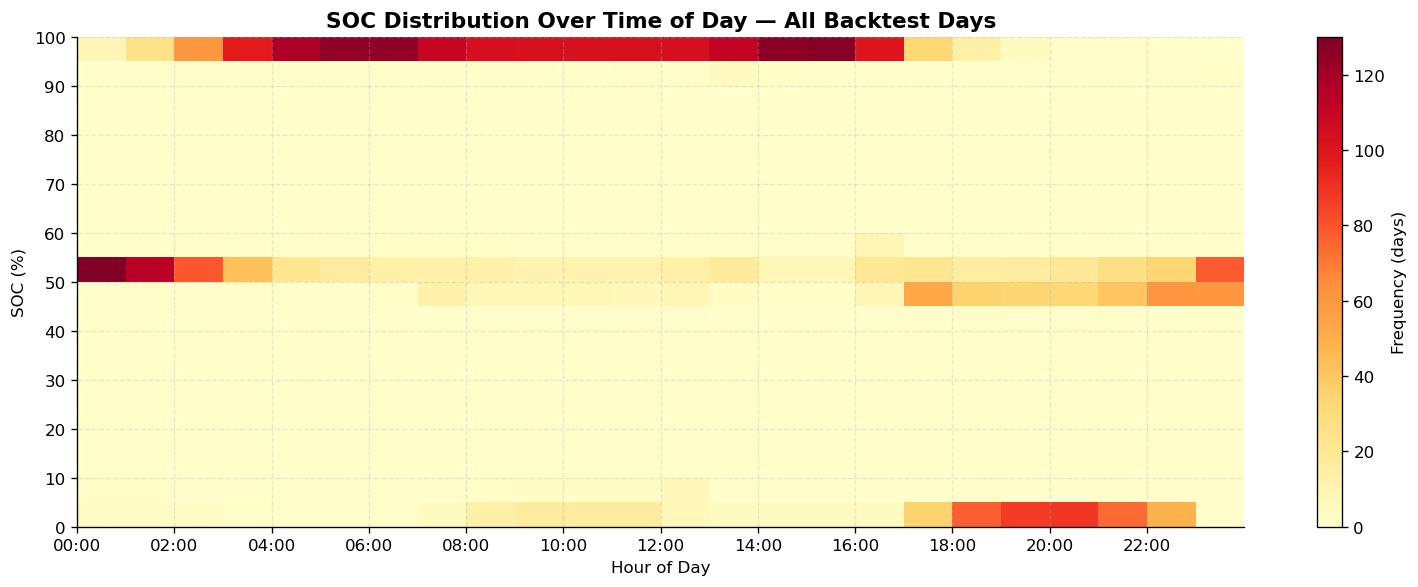

In [11]:
dispatch_df["timestamp"] = pd.to_datetime(dispatch_df["timestamp"])
soc_pct = dispatch_df["soc_after"].values * 100
hour_of_day = dispatch_df["hour"].values

soc_bins = np.arange(0, 105, 5)
hour_bins = np.arange(0, 25)

hist, xedges, yedges = np.histogram2d(hour_of_day, soc_pct, bins=[hour_bins, soc_bins])

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.pcolormesh(xedges, yedges, hist.T, cmap="YlOrRd", shading="flat")
fig.colorbar(im, ax=ax, label="Frequency (days)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("SOC (%)")
ax.set_title("SOC Distribution Over Time of Day — All Backtest Days", fontsize=13, fontweight="bold")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_yticks(range(0, 101, 10))
plt.tight_layout()
plt.show()

### Rebalancing Impact — DA Schedule vs. Final Dispatch

Compares the LP-committed DA schedule with the actual dispatch (after intraday rebalancing) for the same sample day. The gap between the two series shows where the intraday rules engine adjusted volume.

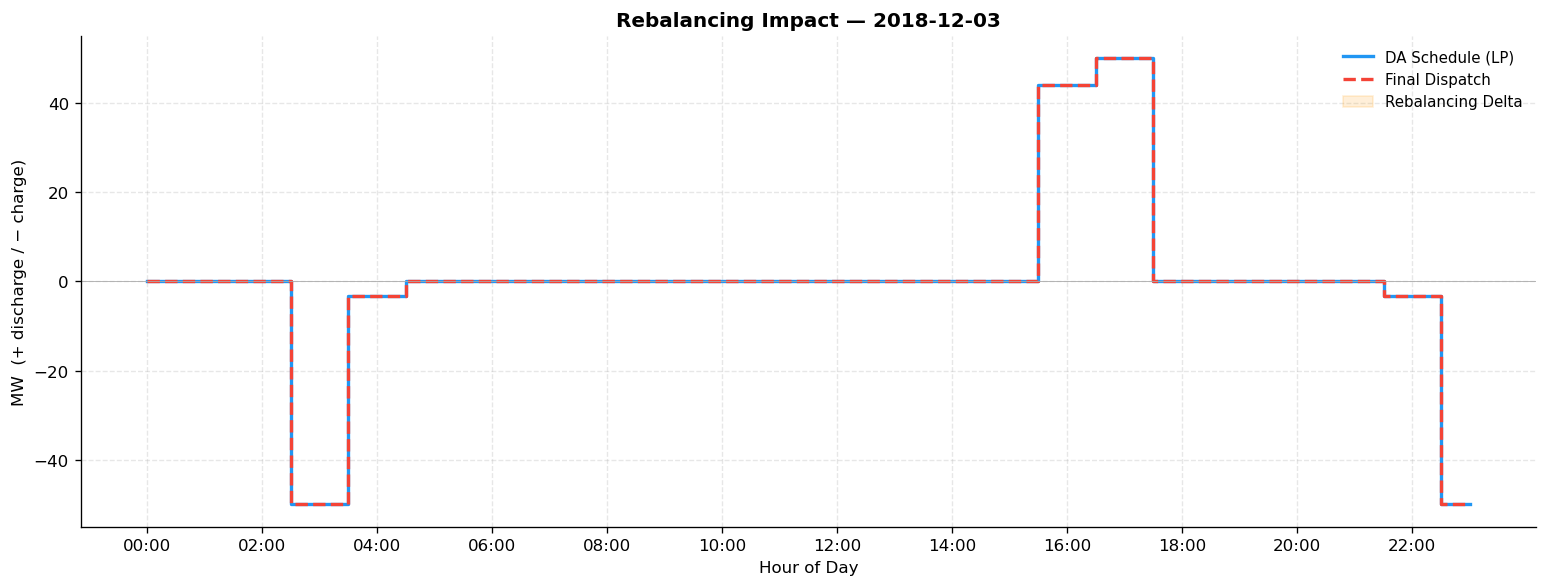

In [12]:
# Re-derive sample-day data so this cell is safe to run independently
day_sched_s  = da_sched_df[da_sched_df["date"] == sample_date].sort_values("hour")
day_disp_s   = dispatch_df[dispatch_df["date"] == sample_date].sort_values("hour")
da_mw_s      = day_sched_s["da_mw"].values
hours_s      = np.arange(len(da_mw_s))

actual_mw = []
for _, row in day_disp_s.iterrows():
    if row["action"] == "discharge":
        actual_mw.append(row["mw"])
    elif row["action"] == "charge":
        actual_mw.append(-row["mw"])
    else:
        actual_mw.append(0.0)
actual_mw = np.array(actual_mw)

fig, ax = plt.subplots(figsize=(13, 5))
ax.step(hours_s, da_mw_s,   where="mid", linewidth=2,   color=COLORS["da"],       label="DA Schedule (LP)")
ax.step(hours_s, actual_mw, where="mid", linewidth=2,   color=COLORS["imbalance"],
        linestyle="--", label="Final Dispatch")
ax.fill_between(hours_s, da_mw_s, actual_mw, alpha=0.15, color=COLORS["degradation"],
                step="mid", label="Rebalancing Delta")
ax.axhline(0, color="#aaaaaa", linewidth=0.5)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MW  (+ discharge / − charge)")
ax.set_title(f"Rebalancing Impact — {sample_date}", fontsize=12, fontweight="bold")
ax.set_xticks(hours_s[::2])
ax.set_xticklabels([f"{h:02d}:00" for h in hours_s[::2]])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


### Dispatch Efficiency

Compares the DA-committed MW schedule with the actual dispatched MW for every period in the backtest. Points on the diagonal indicate perfect execution.

,Value
Metric,
Mean Absolute Deviation,0.097 MW
Periods within ±5% of 50.0 MW,99.8%
Total periods evaluated,"3,452"


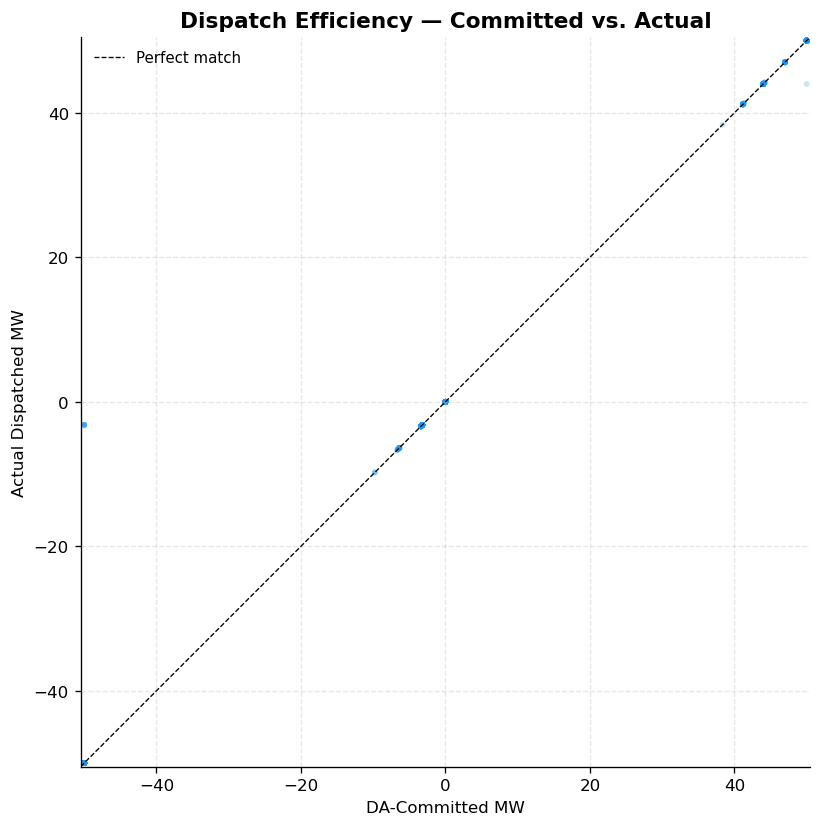

In [13]:
efficiency = da_sched_df.merge(
    dispatch_df[["date", "hour", "action", "mw"]],
    on=["date", "hour"],
    how="inner",
)
efficiency["actual_mw"] = np.where(
    efficiency["action"] == "discharge", efficiency["mw"],
    np.where(efficiency["action"] == "charge", -efficiency["mw"], 0.0),
)
efficiency["deviation"] = efficiency["actual_mw"] - efficiency["da_mw"]

mad = efficiency["deviation"].abs().mean()
power_mw = BESS_CFG["power_mw"]
within_5 = (efficiency["deviation"].abs() <= 0.05 * power_mw).mean() * 100

metrics = pd.DataFrame([
    {"Metric": "Mean Absolute Deviation",               "Value": f"{mad:.3f} MW"},
    {"Metric": f"Periods within ±5% of {power_mw} MW",  "Value": f"{within_5:.1f}%"},
    {"Metric": "Total periods evaluated",                "Value": f"{len(efficiency):,}"},
]).set_index("Metric")
display(metrics.style.set_properties(**{"text-align": "right"}))

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(efficiency["da_mw"], efficiency["actual_mw"],
           alpha=0.25, s=12, color=COLORS["da"], edgecolors="none")
lims = [
    min(efficiency["da_mw"].min(), efficiency["actual_mw"].min()) - 0.5,
    max(efficiency["da_mw"].max(), efficiency["actual_mw"].max()) + 0.5,
]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect match")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("DA-Committed MW")
ax.set_ylabel("Actual Dispatched MW")
ax.set_title("Dispatch Efficiency — Committed vs. Actual", fontsize=13, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Price Capture Analysis

Shows when (by hour of day) the BESS charges vs. discharges relative to the average DA price profile. A well-optimised BESS should discharge at high-price hours and charge at low-price hours. The spread between the weighted-average discharge price and the weighted-average charge price is the **achieved price spread** — the key driver of DA revenue.


Weighted avg discharge price : £87.89/MWh
Weighted avg charge price    : £49.52/MWh
Achieved price spread        : £38.37/MWh
All-day average DA price     : £62.71/MWh


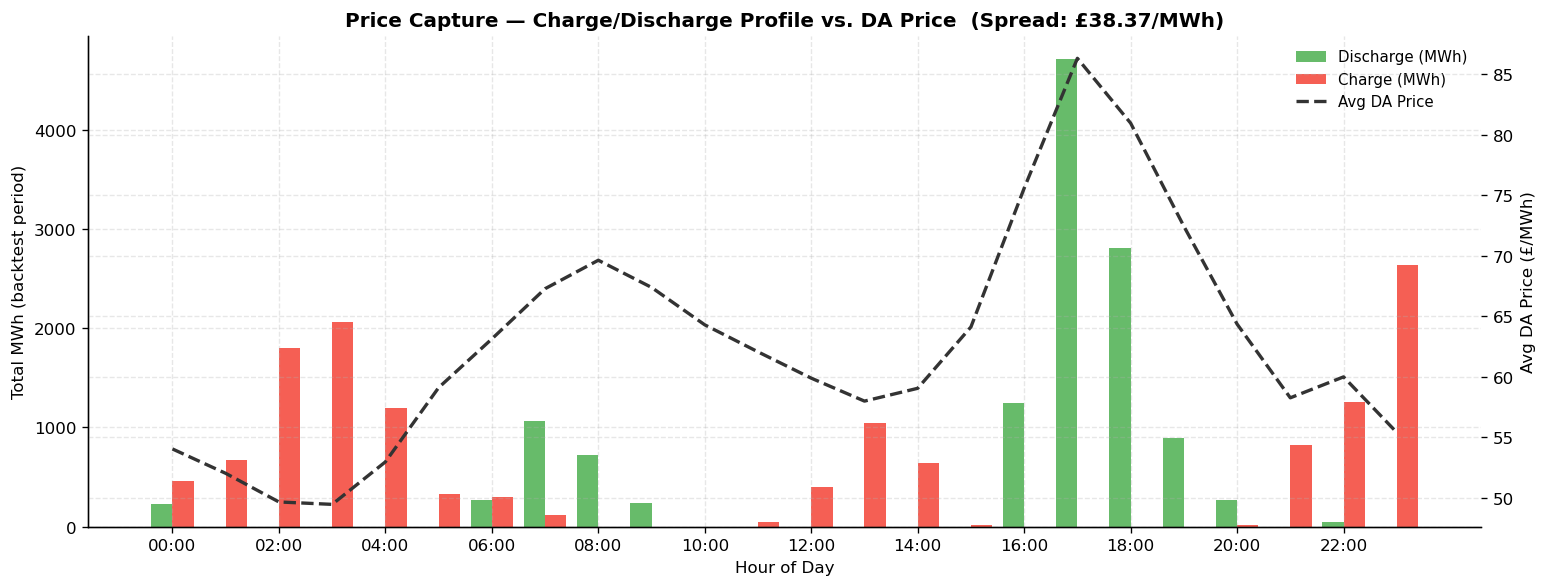

In [14]:
# ── Dispatch by hour of day ────────────────────────────────────────────────────
_ddf = dispatch_df.copy()
_ddf["hod"] = _ddf["hour"]

discharge_mwh = _ddf[_ddf["action"] == "discharge"].groupby("hod")["mw"].sum()
charge_mwh    = _ddf[_ddf["action"] == "charge"].groupby("hod")["mw"].sum()

# Average DA price by hour (across the full analysis period)
prices_hod = prices.copy()
prices_hod["hod"] = prices_hod.index.hour
avg_da_by_hour = prices_hod.groupby("hod")["day_ahead_price"].mean()

# Weighted average charge and discharge prices
_ddf2 = dispatch_df.merge(
    prices[["day_ahead_price"]].rename(columns={"day_ahead_price": "da_p"}),
    left_on="timestamp", right_index=True, how="left",
)
w_discharge = (_ddf2[_ddf2["action"] == "discharge"]["da_p"] * _ddf2[_ddf2["action"] == "discharge"]["mw"]).sum() \
              / _ddf2[_ddf2["action"] == "discharge"]["mw"].sum()
w_charge    = (_ddf2[_ddf2["action"] == "charge"]["da_p"] * _ddf2[_ddf2["action"] == "charge"]["mw"]).sum() \
              / _ddf2[_ddf2["action"] == "charge"]["mw"].sum()
price_spread = w_discharge - w_charge

print(f"Weighted avg discharge price : £{w_discharge:.2f}/MWh")
print(f"Weighted avg charge price    : £{w_charge:.2f}/MWh")
print(f"Achieved price spread        : £{price_spread:.2f}/MWh")
print(f"All-day average DA price     : £{avg_da_by_hour.mean():.2f}/MWh")

# ── Chart ──────────────────────────────────────────────────────────────────────
hod_x = np.arange(24)
fig, ax1 = plt.subplots(figsize=(13, 5))

ax2 = ax1.twinx()
ax2.plot(avg_da_by_hour.reindex(hod_x, fill_value=0).index,
         avg_da_by_hour.reindex(hod_x, fill_value=0).values,
         color="#333333", linewidth=2, linestyle="--", label="Avg DA Price", zorder=5)
ax2.set_ylabel("Avg DA Price (£/MWh)", fontsize=10)
ax2.spines["top"].set_visible(False)

w = 0.4
ax1.bar(hod_x - w/2, discharge_mwh.reindex(hod_x, fill_value=0),
        w, color=COLORS["intraday"], alpha=0.85, label="Discharge (MWh)")
ax1.bar(hod_x + w/2, charge_mwh.reindex(hod_x, fill_value=0),
        w, color=COLORS["imbalance"], alpha=0.85, label="Charge (MWh)")

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Total MWh (backtest period)", fontsize=10)
ax1.set_xticks(hod_x[::2])
ax1.set_xticklabels([f"{h:02d}:00" for h in hod_x[::2]])
ax1.set_title(
    f"Price Capture — Charge/Discharge Profile vs. DA Price  "
    f"(Spread: £{price_spread:.2f}/MWh)",
    fontsize=12, fontweight="bold",
)
ax1.axhline(0, color="#aaaaaa", linewidth=0.5)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


---
## Section 4: Risk Profile

Four-panel risk dashboard: rolling 30-day Sharpe ratio, daily drawdown, daily PnL distribution, and PnL waterfall decomposition.


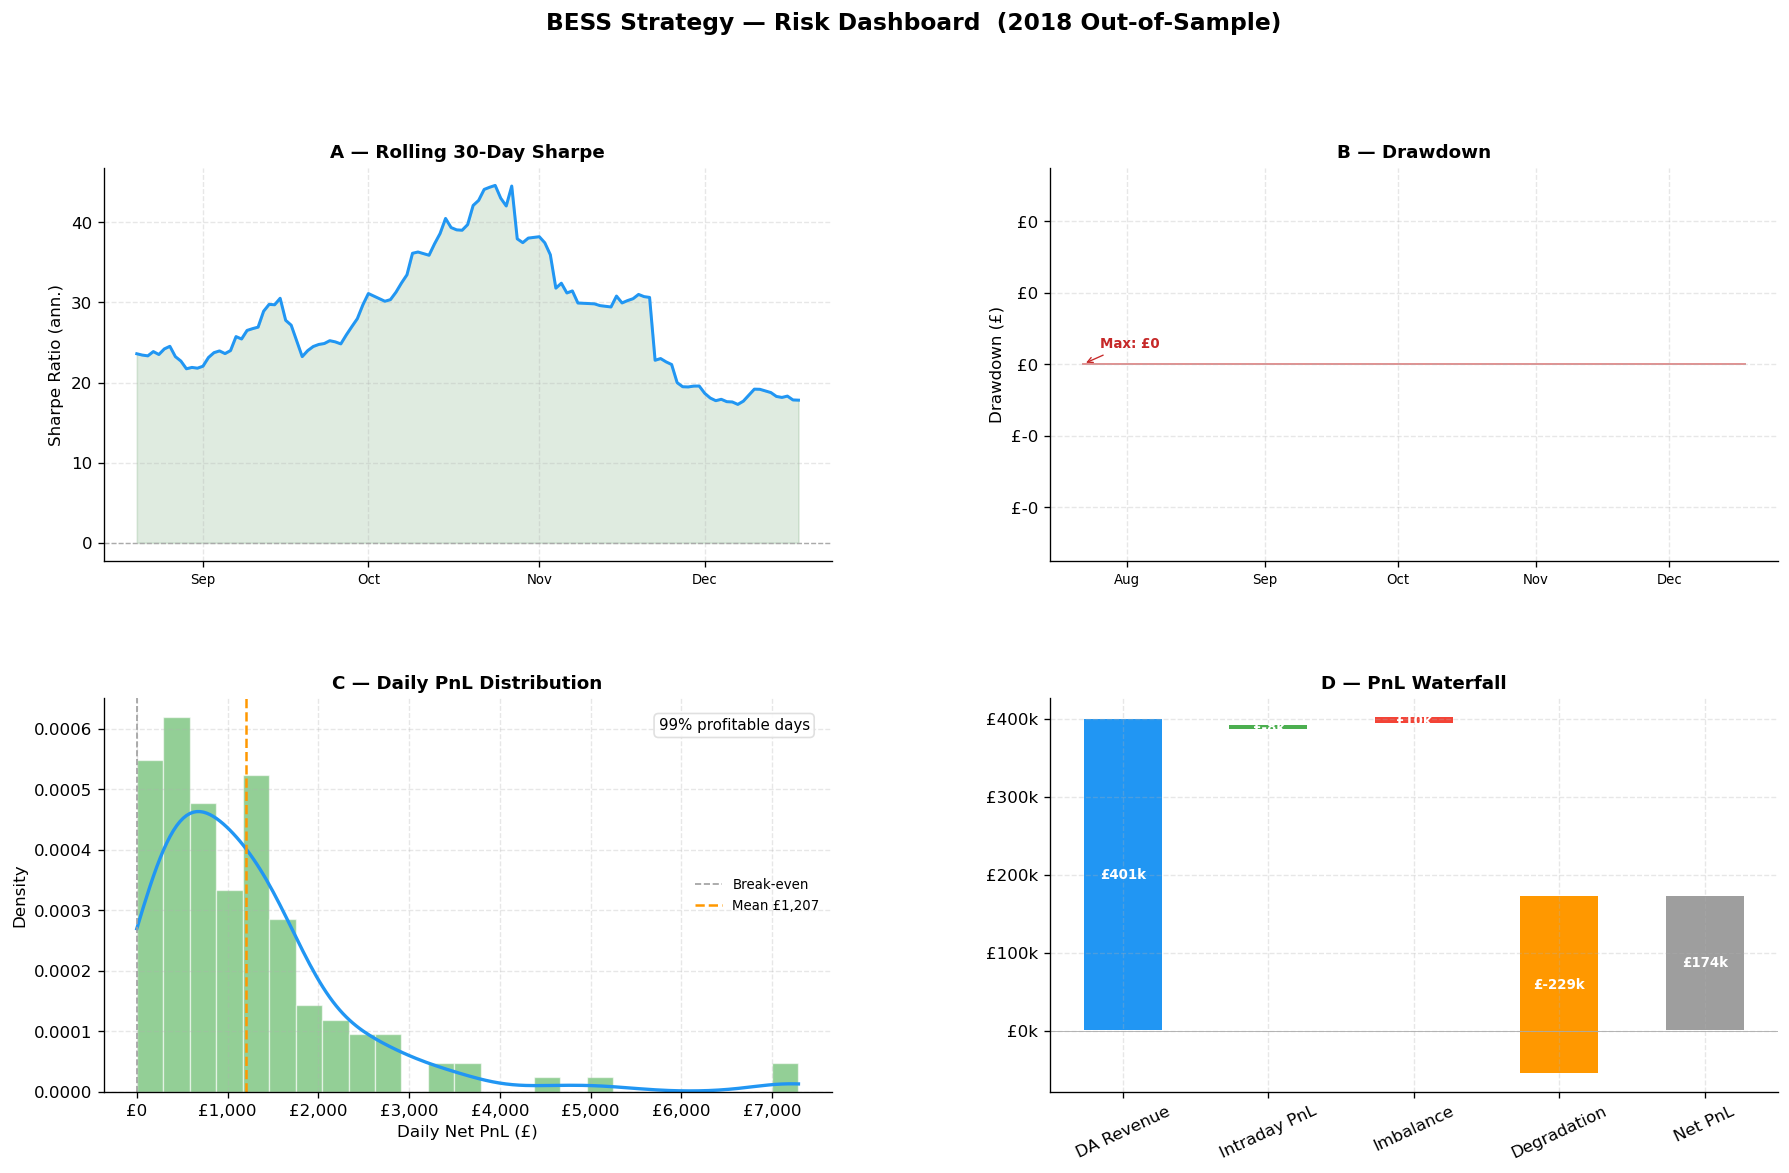

In [15]:
import matplotlib.gridspec as gridspec

# ── Pre-compute rolling metrics ────────────────────────────────────────────────
_pnl_series = results_df.set_index("date")["net_pnl"]
_rolling_w  = 30
_roll_mean  = _pnl_series.rolling(_rolling_w).mean()
_roll_std   = _pnl_series.rolling(_rolling_w).std(ddof=1)
_roll_sharpe = (_roll_mean / _roll_std) * np.sqrt(365)

_equity = STARTING_CAPITAL + _pnl_series.cumsum()
_dd     = _equity - _equity.cummax()

# ── Four-panel figure ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])   # Rolling Sharpe
ax2 = fig.add_subplot(gs[0, 1])   # Drawdown
ax3 = fig.add_subplot(gs[1, 0])   # Daily PnL distribution
ax4 = fig.add_subplot(gs[1, 1])   # PnL waterfall

# ── A: Rolling 30-Day Sharpe ──────────────────────────────────────────────────
ax1.plot(_roll_sharpe.index, _roll_sharpe.values, color=COLORS["da"], linewidth=1.8)
ax1.fill_between(_roll_sharpe.index, 0, _roll_sharpe.values,
                 where=(_roll_sharpe.values >= 0), alpha=0.15, color="#2E7D32")
ax1.fill_between(_roll_sharpe.index, 0, _roll_sharpe.values,
                 where=(_roll_sharpe.values < 0),  alpha=0.15, color="#C62828")
ax1.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle="--")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.set_title(f"A — Rolling {_rolling_w}-Day Sharpe", fontsize=11, fontweight="bold")
ax1.set_ylabel("Sharpe Ratio (ann.)")
ax1.tick_params(axis="x", labelsize=8)

# ── B: Drawdown ───────────────────────────────────────────────────────────────
ax2.fill_between(_dd.index, _dd.values, 0, alpha=0.5, color="#C62828")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax2.set_title("B — Drawdown", fontsize=11, fontweight="bold")
ax2.set_ylabel("Drawdown (£)")
ax2.tick_params(axis="x", labelsize=8)
ax2.annotate(f"Max: £{_dd.min():,.0f}",
             xy=(_dd.index[_dd.argmin()], _dd.min()),
             xytext=(10, 10), textcoords="offset points",
             fontsize=8, color="#C62828", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#C62828", lw=0.8))

# ── C: Daily PnL distribution ─────────────────────────────────────────────────
_dpnl = results_df["net_pnl"].values
_mean = _dpnl.mean()
_pct_pos = (_dpnl > 0).mean() * 100

ax3.hist(_dpnl, bins=25, density=True, alpha=0.6, color=COLORS["intraday"],
         edgecolor="white", linewidth=0.8)
_x_kde = np.linspace(_dpnl.min(), _dpnl.max(), 200)
ax3.plot(_x_kde, gaussian_kde(_dpnl)(_x_kde), linewidth=2, color=COLORS["da"])
ax3.axvline(0,      color=COLORS["net"],         linewidth=1, linestyle="--", label="Break-even")
ax3.axvline(_mean,  color=COLORS["degradation"], linewidth=1.5, linestyle="--",
            label=f"Mean £{_mean:,.0f}")
ax3.set_xlabel("Daily Net PnL (£)")
ax3.set_ylabel("Density")
ax3.set_title("C — Daily PnL Distribution", fontsize=11, fontweight="bold")
ax3.legend(frameon=False, fontsize=8)
ax3.text(0.97, 0.95, f"{_pct_pos:.0f}% profitable days",
         transform=ax3.transAxes, ha="right", va="top", fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#dddddd", alpha=0.9))
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

# ── D: PnL waterfall decomposition ────────────────────────────────────────────
_wf = {
    "DA Revenue":   results_df["da_revenue"].sum(),
    "Intraday PnL": results_df["intraday_pnl"].sum(),
    "Imbalance":    results_df["imbalance_pnl"].sum(),
    "Degradation":  -results_df["degradation_cost"].sum(),
}
_wf_net = sum(_wf.values())
_wf_labels = list(_wf.keys()) + ["Net PnL"]
_wf_values = list(_wf.values()) + [_wf_net]

_run = 0.0; _bots = []
for v in list(_wf.values()):
    _bots.append(_run if v >= 0 else _run + v)
    _run += v
_bots.append(0.0)

_wf_colors = [COLORS["da"], COLORS["intraday"], COLORS["imbalance"],
              COLORS["degradation"], COLORS["net"]]
bars = ax4.bar(_wf_labels, _wf_values, bottom=_bots, color=_wf_colors, width=0.55,
               edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, _wf_values):
    y = bar.get_y() + bar.get_height() / 2
    ax4.text(bar.get_x() + bar.get_width() / 2, y, f"£{val/1000:.0f}k",
             ha="center", va="center", fontsize=8, fontweight="bold", color="white")
ax4.axhline(0, color="#aaaaaa", linewidth=0.5)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k"))
ax4.set_title("D — PnL Waterfall", fontsize=11, fontweight="bold")
ax4.tick_params(axis="x", rotation=25)

fig.suptitle("BESS Strategy — Risk Dashboard  (2018 Out-of-Sample)",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("assets/bess_risk_dashboard.png", dpi=150, bbox_inches="tight", facecolor="#ffffff")
plt.show()
